<div style="text-align:center">

# Лабораторная работа №3
## Анализ временных рядов



</div>

## Постановка задачи

Дан набор данных `sell.csv` - продажи **60 вариантов** товара за **$N = 50$ дней**. Для каждого варианта пять натуральных метрик ($\text{мыло, порошок, средство, краска, пена}$) в штуках и целевая переменная $\text{прибыль}$ в тыс. руб.

Номер варианта определяется как

$$V = \bigl(\, \mathrm{ISU}_1 + \mathrm{ISU}_2 \,\bigr) \bmod 60 \;=\; (465430 + 467715) \bmod 60 \;=\; 25.$$

Лабораторная состоит из четырёх задач:

- **Задача 1.** Реализовать три фильтра + hard-добавку (вейвлет/LMS).
- **Задача 2.** Прогнать фильтры по данным варианта, построить графики.
- **Задача 3.** Вычислить характеристики ряда: тренд, стационарность, периодичность, корреляции.
- **Задача 4 (Hard).** Найти данные с двумя датчиками и применить фильтрацию + анализ.

Вся бизнес-логика - в [`./src/`](./src/); ноутбук импортирует и визуализирует.

## Подготовка окружения

In [1]:
# Поиск lab_03/src/ и фиксация рабочей директории
import os, sys
from pathlib import Path

_cwd = Path(os.getcwd()).resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _src = _candidate / 'lab_03' / 'src'
    if _src.is_dir() and (_src / 'utils.py').exists():
        break
    _src = _candidate / 'src'
    if _src.is_dir() and (_src / 'utils.py').exists():
        break
else:
    raise RuntimeError('Не нашёл lab_03/src/ - запусти ноутбук из lab_03/ или её родителя')
os.chdir(_src.parent)
sys.path.insert(0, str(_src))
print('Working dir:', os.getcwd())

Working dir: C:\Users\splix\PycharmProjects\Lab_3_metopt\lab3


In [2]:
# Импорты и стиль
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils, eda, periodicity, correlations, filters, wavelet_lms, task4_sensors

utils.seed_everything(42)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.precision', 4)
plt.rcParams['figure.dpi'] = 110

In [3]:
# Загрузка варианта 25
ISU = [465430, 467715]
V = utils.compute_variant(ISU)
df = utils.load_variant('sell.csv', V)
print(f'Вариант: {V},  shape: {df.shape},  колонки: {list(df.columns)}')
df.head()

Вариант: 25,  shape: (50, 6),  колонки: ['мыло', 'порошок', 'средство', 'краска', 'пена', 'прибыль']


,мыло,порошок,средство,краска,пена,прибыль
day,,,,,,
1,126.0,19.0,25.0,42.0,18.0,30.943
2,75.0,16.0,17.0,46.0,21.0,28.941
3,127.0,23.0,26.0,43.0,24.0,31.571
4,88.0,18.0,23.0,43.0,22.0,26.179
5,68.0,20.0,15.0,42.0,20.0,24.269


## Задача 1. Реализация фильтров

**1.1 Скользящее среднее и экспоненциальное сглаживание.** Центрированное MA с симметричным `edge`-паддингом и Brown

$$\hat x_t = \alpha\, x_t + (1 - \alpha)\, \hat x_{t-1}, \qquad \hat x_0 = x_0,\quad 0 < \alpha \le 1.$$

**1.2 Калман на модели случайного блуждания (RW).** Скалярный, с обратным RTS-проходом:

$$x_t = x_{t-1} + w_t,\; w_t \sim \mathcal{N}(0, Q), \qquad z_t = x_t + v_t,\; v_t \sim \mathcal{N}(0, R).$$

Параметры $Q, R$ оцениваются методом моментов из вторых разностей наблюдений.

**1.3 Фильтр Савицкого-Голея.** Локальная полиномиальная регрессия степени $p$ на окне $w$ через `scipy.signal.savgol_filter`.

**1.4 Hard.** *DWT-денойзинг*: разложение `pywt.wavedec`, оценка $\sigma$ через MAD/0.6745 по первому уровню деталей, универсальный порог Donoho $\lambda = \sigma\sqrt{2\ln N}$ + soft-thresholding. *LMS-адаптивный* в режиме предсказания по $n_\text{taps}$ предыдущим значениям, шаг $\mu$ - из условия устойчивости.

### Демонстрация на синтетике

Тестовый сигнал длиной 200 точек:

$$x_t = \sin\!\bigl(2\pi t / 30\bigr) + \tfrac{1}{2}\sin\!\bigl(2\pi t / 8\bigr) + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\, 0.5^2).$$

Истина известна - считаем честный MSE.

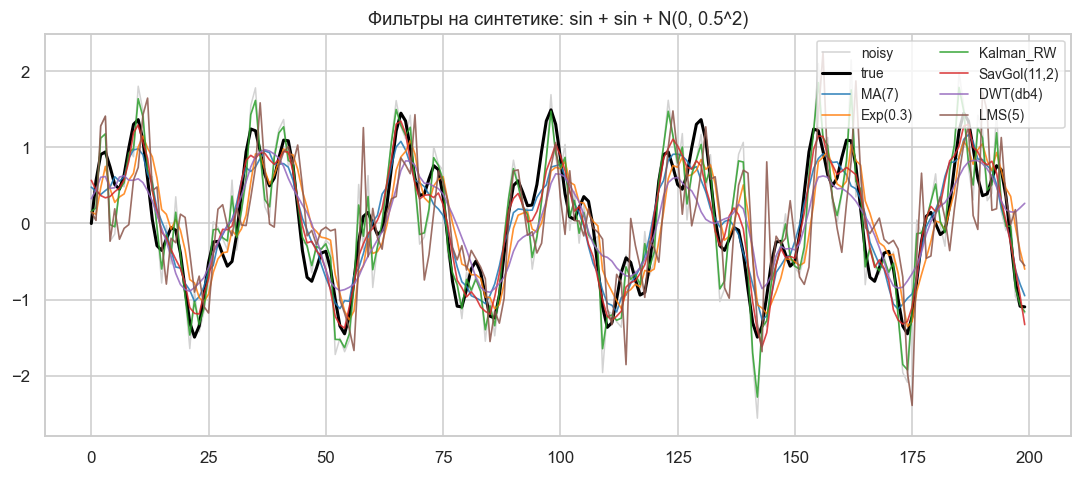

In [4]:
# Синтетический сигнал и все 6 фильтров
rng = np.random.default_rng(42)
n = 200
t = np.arange(n)
true = np.sin(2*np.pi*t/30) + 0.5*np.sin(2*np.pi*t/8)
noisy = true + rng.normal(0, 0.5, n)
demo = pd.DataFrame({
    'true': true, 'noisy': noisy,
    'MA(7)':        filters.moving_average(noisy, window=7),
    'Exp(0.3)':     filters.exponential_smoothing(noisy, alpha=0.3),
    'Kalman_RW':    filters.kalman_1d_rw(noisy),
    'SavGol(11,2)': filters.savitzky_golay(noisy, window=11, polyorder=2),
    'DWT(db4)':     wavelet_lms.dwt_denoise(noisy)['denoised'][:n],
    'LMS(5)':       wavelet_lms.lms_denoise(noisy, n_taps=5)['denoised'],
})

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, demo['noisy'], color='lightgray', lw=1, label='noisy')
ax.plot(t, demo['true'],  color='black',     lw=2, label='true')
for col, c in zip(['MA(7)','Exp(0.3)','Kalman_RW','SavGol(11,2)','DWT(db4)','LMS(5)'],
                   ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']):
    ax.plot(t, demo[col], lw=1.1, label=col, color=c, alpha=0.85)
ax.set_title('Фильтры на синтетике: sin + sin + N(0, 0.5^2)')
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout(); plt.savefig('figures/filters_demo_synthetic.png', dpi=120)
plt.show()

In [5]:
# MSE и smoothing_degree относительно истины
demo_metrics = pd.DataFrame({
    col: filters.filter_metrics(true, demo[col].values)
    for col in ['MA(7)','Exp(0.3)','Kalman_RW','SavGol(11,2)','DWT(db4)','LMS(5)']
}).T
demo_metrics.round(4)

,MSE,MAE,RMSE,residual_var,bias,smoothing_degree
MA(7),0.1156,0.2906,0.3400,0.1159,0.0162,0.2830
Exp(0.3),0.1945,0.3583,0.4410,0.1954,0.0064,0.3098
Kalman_RW,0.1212,0.2804,0.3481,0.1216,0.0152,-0.1865
"SavGol(11,2)",0.0811,0.2344,0.2847,0.0812,0.0169,0.0938
DWT(db4),0.2299,0.3882,0.4795,0.2308,0.0166,0.5522
LMS(5),0.3873,0.5105,0.6224,0.3893,0.0019,0.0950


## Задача 2. Применение фильтров к данным варианта 25

По требованию README - графики обязательны. Рассматриваем две ключевые метрики: $\text{прибыль}$ и $\text{мыло}$ (самая объёмная номенклатура и, как покажет Задача 3, главный драйвер прибыли).

Без истинного сигнала MSE отражает не точность, а интенсивность сглаживания. Содержательная метрика -

$$\text{smoothing\_degree}(\hat x) = 1 - \frac{\mathrm{Var}(\hat x)}{\mathrm{Var}(x)}.$$

In [6]:
# Прогон всех фильтров по прибыли и мылу варианта 25
series_profit = df[utils.PROFIT_COL]
series_soap   = df['мыло']

core_profit = filters.apply_all_core(series_profit)
hard_profit = wavelet_lms.apply_all_hard(series_profit)
core_soap   = filters.apply_all_core(series_soap)
hard_soap   = wavelet_lms.apply_all_hard(series_soap)
core_profit.head()

,original,MA(5),MA(7),Exp(a=0.3),Exp(a=0.5),Holt,Kalman_RW,"SavGol(7,2)"
day,,,,,,,,
1,30.943,30.6682,30.0661,30.9430,30.9430,28.9410,29.9860,31.6819
2,28.941,29.7154,29.1127,30.3424,29.9420,26.9390,29.3860,29.5944
3,31.571,28.3806,28.2884,30.7110,30.7565,26.4656,28.8934,27.9823
4,26.179,27.2266,27.7961,29.3514,28.4678,24.5080,27.7544,26.8455
5,24.269,26.9378,27.3116,27.8267,26.3684,22.5575,26.9958,25.8198


In [7]:
# Таблица метрик качества фильтрации для прибыли
all_filtered_profit = pd.concat([core_profit, hard_profit.drop(columns='original')], axis=1)
rows = {}
for col in all_filtered_profit.columns:
    if col == 'original':
        continue
    m = filters.filter_metrics(series_profit.values, all_filtered_profit[col].values)
    rows[col] = {k.upper() if k.upper() in ('MSE','MAE','RMSE') else k: v for k, v in m.items()}
metrics_profit = pd.DataFrame(rows).T
metrics_profit.round(4)

,MSE,MAE,RMSE,residual_var,bias,smoothing_degree
MA(5),2.2871,1.1874,1.5123,2.3336,-0.0133,0.7274
MA(7),2.4166,1.2223,1.5545,2.4654,-0.0215,0.8136
Exp(a=0.3),1.9370,1.0692,1.3918,1.9615,-0.1214,0.6597
Exp(a=0.5),1.0314,0.7944,1.0156,1.0504,-0.0447,0.5488
Holt,6.2381,1.8656,2.4976,4.1867,1.4612,-0.0674
Kalman_RW,1.9314,1.0947,1.3898,1.9699,-0.0306,0.8232
"SavGol(7,2)",2.0542,1.1060,1.4332,2.0961,0.0049,0.5447
DWT(db4),2.3753,1.2089,1.5412,2.4234,0.0194,0.7243
DWT(sym4),2.0749,1.1169,1.4405,2.1149,0.0476,0.7515
"LMS(5,auto)",3.3222,1.4226,1.8227,3.3856,-0.0657,0.5907


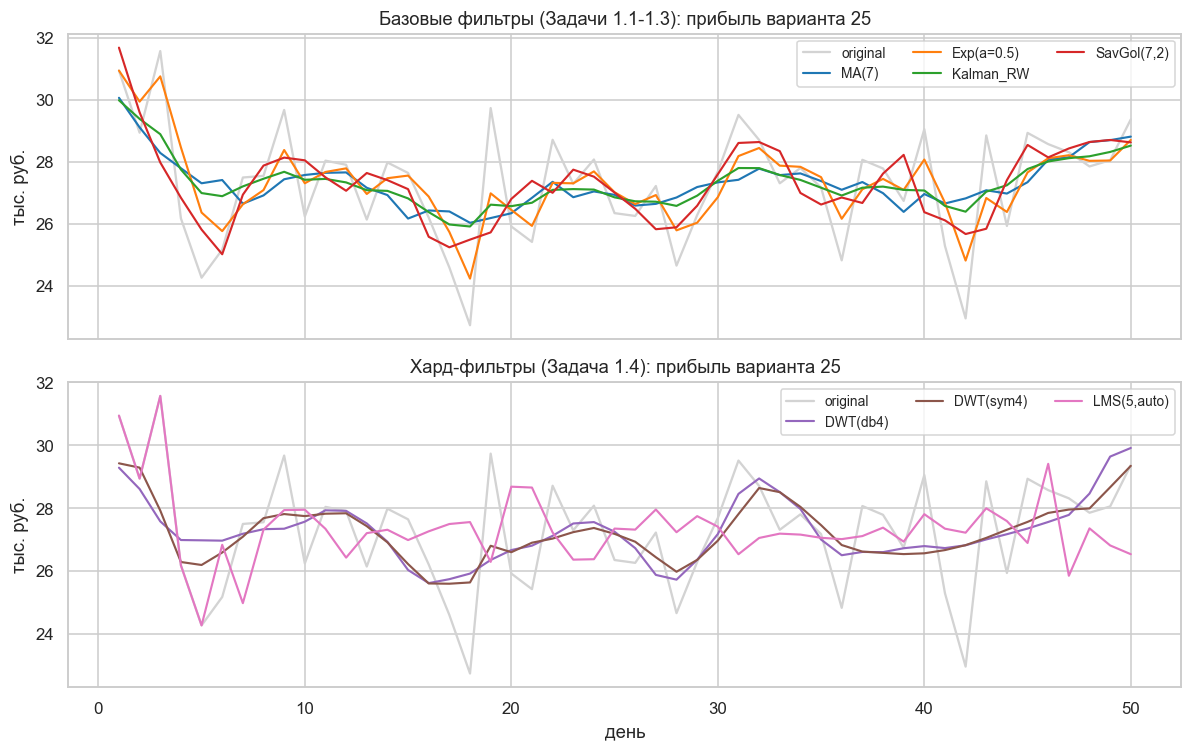

In [8]:
# График: базовые и хард-фильтры на прибыли
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(series_profit.index, series_profit.values, color='lightgray', label='original')
for col, c in zip(['MA(7)','Exp(a=0.5)','Kalman_RW','SavGol(7,2)'],
                   ['#1f77b4','#ff7f0e','#2ca02c','#d62728']):
    axes[0].plot(series_profit.index, core_profit[col].values, lw=1.4, label=col, color=c)
axes[0].set_title('Базовые фильтры (Задачи 1.1-1.3): прибыль варианта 25')
axes[0].set_ylabel('тыс. руб.'); axes[0].legend(ncol=3, fontsize=9)

axes[1].plot(series_profit.index, series_profit.values, color='lightgray', label='original')
for col, c in zip(['DWT(db4)','DWT(sym4)','LMS(5,auto)'],
                   ['#9467bd','#8c564b','#e377c2']):
    axes[1].plot(series_profit.index, hard_profit[col].values, lw=1.4, label=col, color=c)
axes[1].set_title('Хард-фильтры (Задача 1.4): прибыль варианта 25')
axes[1].set_xlabel('день'); axes[1].set_ylabel('тыс. руб.'); axes[1].legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.savefig('figures/task2_filters_profit.png', dpi=120)
plt.show()

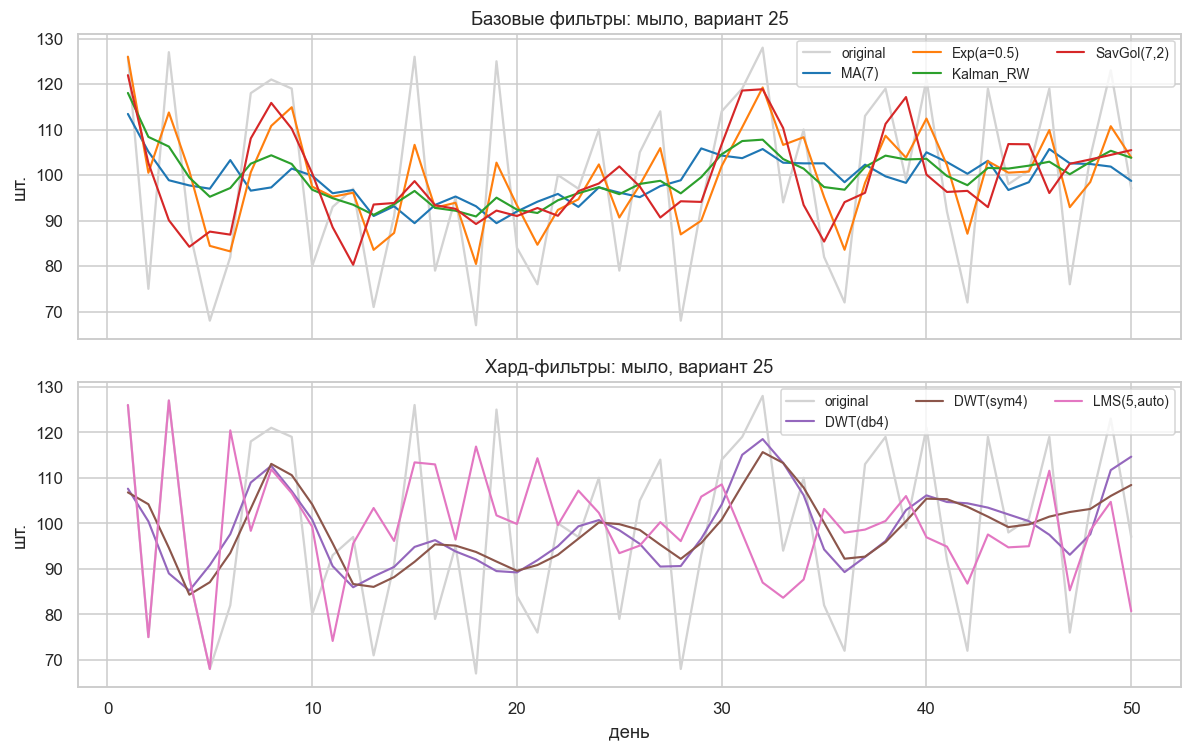

In [9]:
# Те же фильтры на мыле
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(series_soap.index, series_soap.values, color='lightgray', label='original')
for col, c in zip(['MA(7)','Exp(a=0.5)','Kalman_RW','SavGol(7,2)'],
                   ['#1f77b4','#ff7f0e','#2ca02c','#d62728']):
    axes[0].plot(series_soap.index, core_soap[col].values, lw=1.4, label=col, color=c)
axes[0].set_title('Базовые фильтры: мыло, вариант 25')
axes[0].set_ylabel('шт.'); axes[0].legend(ncol=3, fontsize=9)

axes[1].plot(series_soap.index, series_soap.values, color='lightgray', label='original')
for col, c in zip(['DWT(db4)','DWT(sym4)','LMS(5,auto)'],
                   ['#9467bd','#8c564b','#e377c2']):
    axes[1].plot(series_soap.index, hard_soap[col].values, lw=1.4, label=col, color=c)
axes[1].set_title('Хард-фильтры: мыло, вариант 25')
axes[1].set_xlabel('день'); axes[1].set_ylabel('шт.'); axes[1].legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.savefig('figures/task2_filters_soap.png', dpi=120)
plt.show()

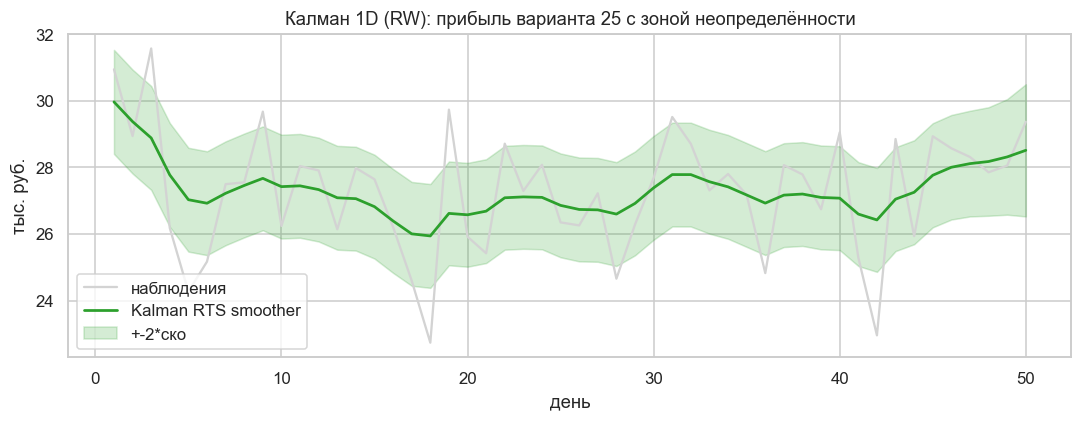

In [10]:
# Калман RTS-сглаживатель с зоной неопределенности +-2*ско
kf = filters.KalmanFilter1D(Q=0.6, R=2.6)
x_s, P_s = kf.smooth(series_profit.values)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(series_profit.index, series_profit.values, color='lightgray', label='наблюдения')
ax.plot(series_profit.index, x_s, color='#2ca02c', lw=1.8, label='Kalman RTS smoother')
ax.fill_between(series_profit.index, x_s - 2*np.sqrt(P_s), x_s + 2*np.sqrt(P_s),
                color='#2ca02c', alpha=0.2, label='+-2*ско')
ax.set_title('Калман 1D (RW): прибыль варианта 25 с зоной неопределённости')
ax.set_xlabel('день'); ax.set_ylabel('тыс. руб.'); ax.legend()
plt.tight_layout(); plt.savefig('figures/task2_kalman_uncertainty.png', dpi=120)
plt.show()

## Задача 3. Характеристики временного ряда

Считаем: описательные статистики, линейный и Манна-Кендалла тренд, ADF/KPSS, ACF/PACF, FFT после удаления тренда, STL-декомпозицию, Pearson/Spearman/частные корреляции, кросс-корреляции с лагами, взаимную информацию.

**Ограничение $N=50$.** ACF теряет мощность на лагах $> N/2 - 1 = 24$; KPSS p-value табулирован только в $[0.01, 0.10]$ - верхняя граница клампится; STL требует $\ge 4$ полных циклов, т.е. $P \le N/3 \approx 16$. Все спектральные оценки за пределами - ориентировочные.

### 3.1 Описательная статистика, тренд, стационарность

In [11]:
# Описательная статистика
stats = eda.descriptive_stats(df)
stats.round(3)

,mean,std,min,q25,median,q75,max,skewness,kurtosis,CV
мыло,98.920,19.040,67.000,82.000,97.500,118.750,128.000,-0.088,-1.274,0.192
порошок,20.380,5.447,9.000,17.000,19.000,23.000,37.000,0.758,0.851,0.267
средство,21.480,3.059,14.000,19.000,22.000,24.000,27.000,-0.258,-0.463,0.142
краска,42.920,1.712,40.000,42.000,43.000,44.000,47.000,0.332,-0.453,0.040
пена,19.920,2.248,16.000,18.000,20.000,21.750,25.000,0.429,-0.584,0.113
прибыль,27.281,1.848,22.738,26.186,27.597,28.508,31.571,-0.280,0.092,0.068


In [12]:
# Тренд: линейная регрессия (lr) и Манна-Кендалла (mk)
trend = {col: eda.trend_analysis(df[col], name=col) for col in utils.ALL_METRIC_COLS}
pd.DataFrame(trend).T[['lr_slope','lr_p','mk_tau','mk_p']].round(4)

,lr_slope,lr_p,mk_tau,mk_p
мыло,0.1389,0.4624,0.0874,0.3747
порошок,-0.0192,0.7236,-0.0588,0.5567
средство,0.0184,0.544,0.0341,0.7362
краска,-0.0031,0.8569,0.008,0.9388
пена,0.0129,0.5645,0.0521,0.6116
прибыль,0.0001,0.9938,0.0661,0.4981


In [13]:
# Стационарность: тесты ADF и KPSS
stat = {col: eda.stationarity_tests(df[col]) for col in utils.ALL_METRIC_COLS}
pd.DataFrame({c: {'adf_p': v['adf_p'], 'kpss_p': v['kpss_p'], 'verdict': v['verdict']}
              for c, v in stat.items()}).T

,adf_p,kpss_p,verdict
мыло,0.0,0.1,stationary
порошок,0.0016,0.1,stationary
средство,0.0,0.1,stationary
краска,0.0306,0.1,stationary
пена,0.0,0.1,stationary
прибыль,0.0,0.1,stationary


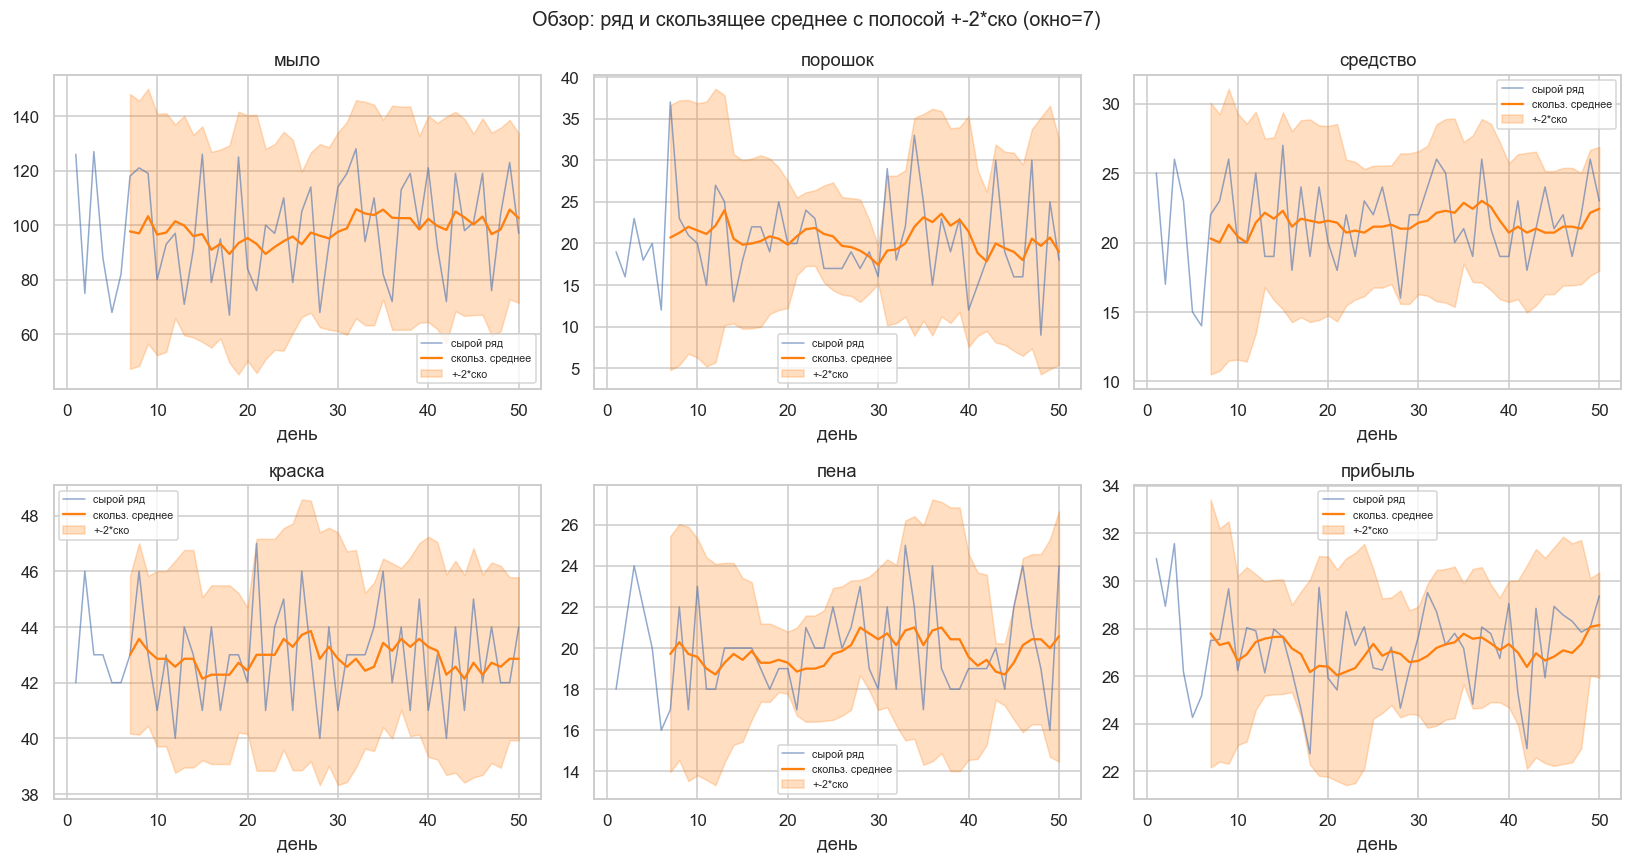

In [14]:
# Обзор шести рядов: сырая + скользящее среднее с полосой +-2*ско
eda.plot_overview(df, save_path='figures/eda_overview.png')
plt.show()

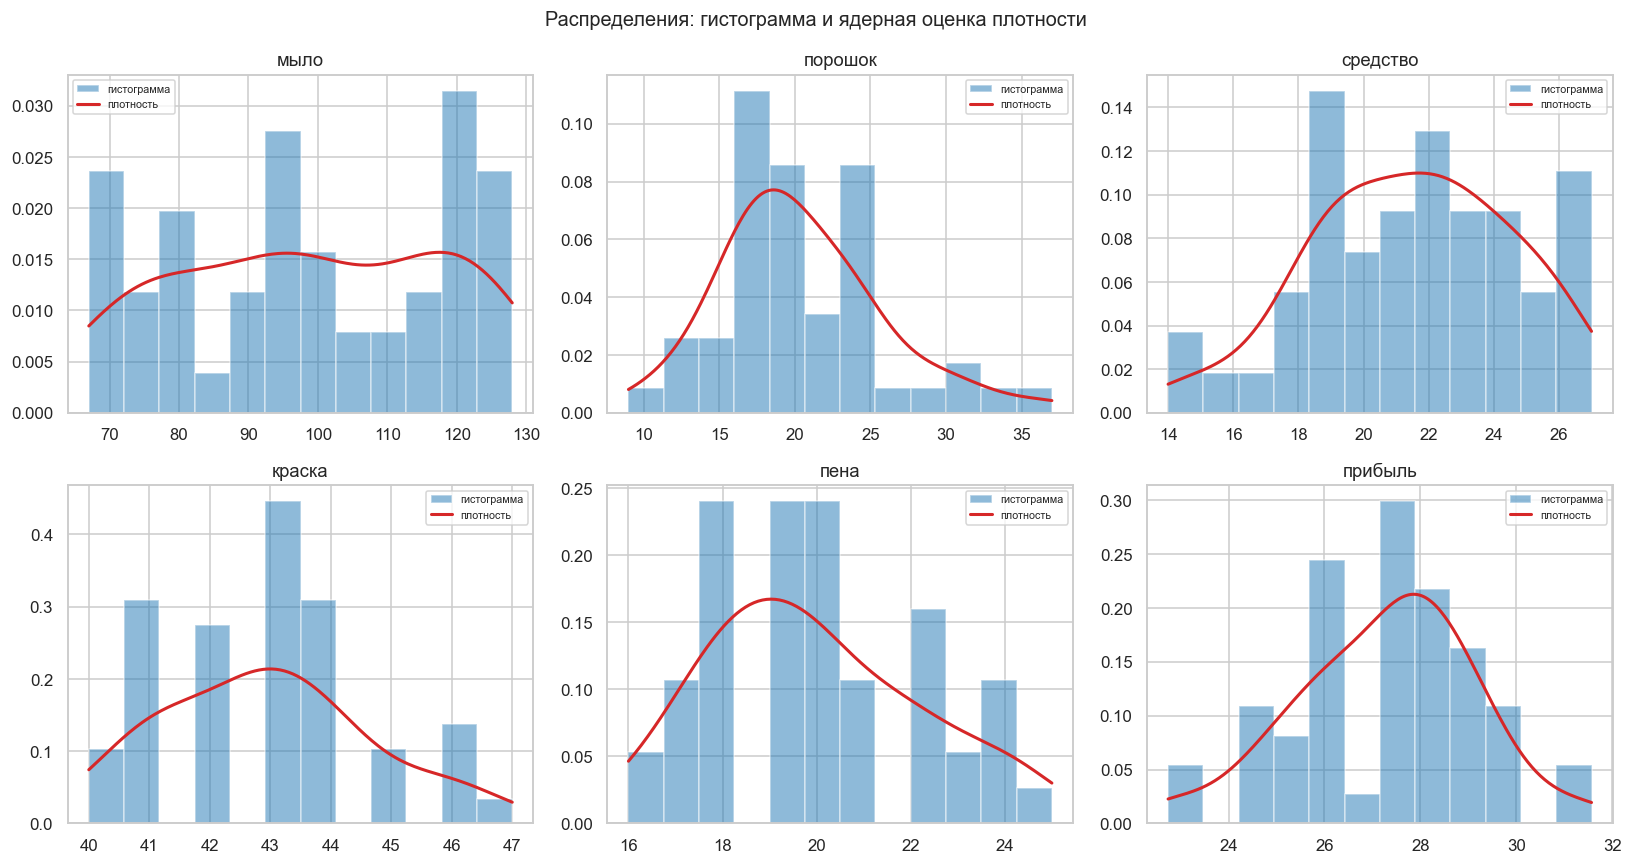

In [15]:
# Распределения: гистограмма и оценка плотности
eda.plot_distributions(df, save_path='figures/eda_distributions.png')
plt.show()

### 3.2 Периодичность

Силу сезонности оцениваем как

$$F_s = \max\!\left(0,\; 1 - \frac{\mathrm{Var}(R)}{\mathrm{Var}(S + R)}\right),$$

где $S, R$ - сезонная и остаточная компоненты STL-разложения.

In [16]:
# ACF и PACF: значимые лаги для прибыли
acf_profit = periodicity.acf_pacf(df[utils.PROFIT_COL], nlags=20)
print('Значимые лаги ACF  (прибыль):', acf_profit['significant_acf'])
print('Значимые лаги PACF (прибыль):', acf_profit['significant_pacf'])

Значимые лаги ACF  (прибыль): []
Значимые лаги PACF (прибыль): []


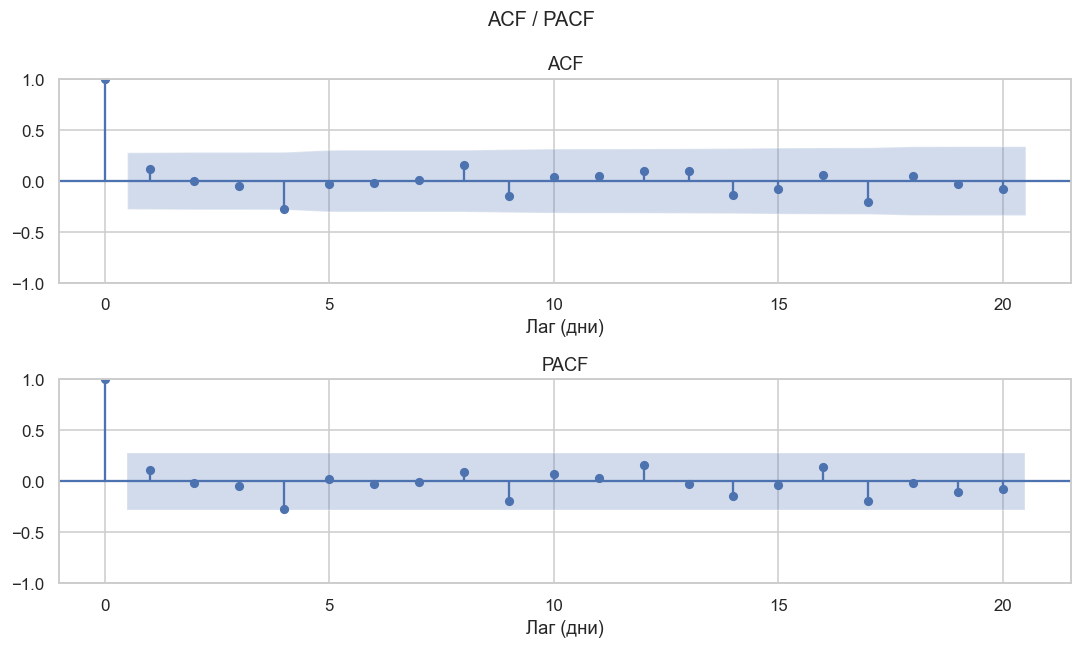

In [17]:
periodicity.plot_acf_pacf(df[utils.PROFIT_COL],
                           save_path='figures/acf_pacf_прибыль.png', nlags=20)
plt.show()

In [18]:
# FFT-спектр после удаления тренда: топ-3 доминирующих периода
fft_profit = periodicity.fft_spectrum(df[utils.PROFIT_COL], detrend=True)
for d in fft_profit['dominant_periods']:
    print(f"period = {d['period_days']:5.2f} д.    freq = {d['freq']:.3f}    power = {d['power']:.2f}")

period =  2.63 д.    freq = 0.380    power = 700.18
period =  6.25 д.    freq = 0.160    power = 451.84
period =  7.14 д.    freq = 0.140    power = 448.62


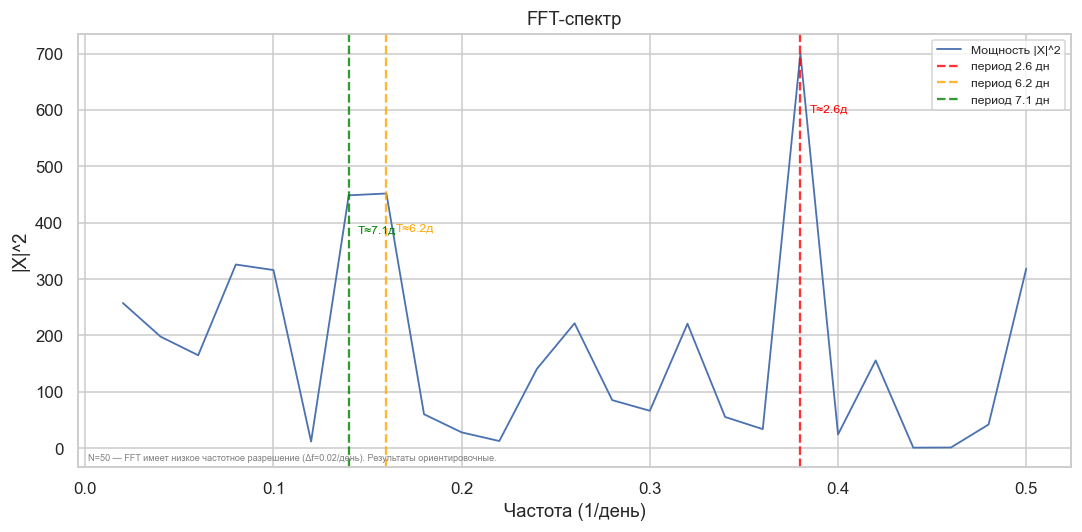

In [19]:
periodicity.plot_fft(df[utils.PROFIT_COL],
                      save_path='figures/fft_прибыль.png', top_k=3)
plt.show()

In [20]:
# STL-декомпозиция: гипотезы периода P=7 (недельная) и P=12
stl7  = periodicity.stl_decomposition(df[utils.PROFIT_COL], period=7)
stl12 = periodicity.stl_decomposition(df[utils.PROFIT_COL], period=12)
pd.DataFrame({'P=7':  {'Fs_stl': stl7['Fs_stl'],  'Ft_stl': stl7['Ft_stl']},
              'P=12': {'Fs_stl': stl12['Fs_stl'], 'Ft_stl': stl12['Ft_stl']}}).round(3)

,P=7,P=12
Fs_stl,0.164,0.375
Ft_stl,0.119,0.082


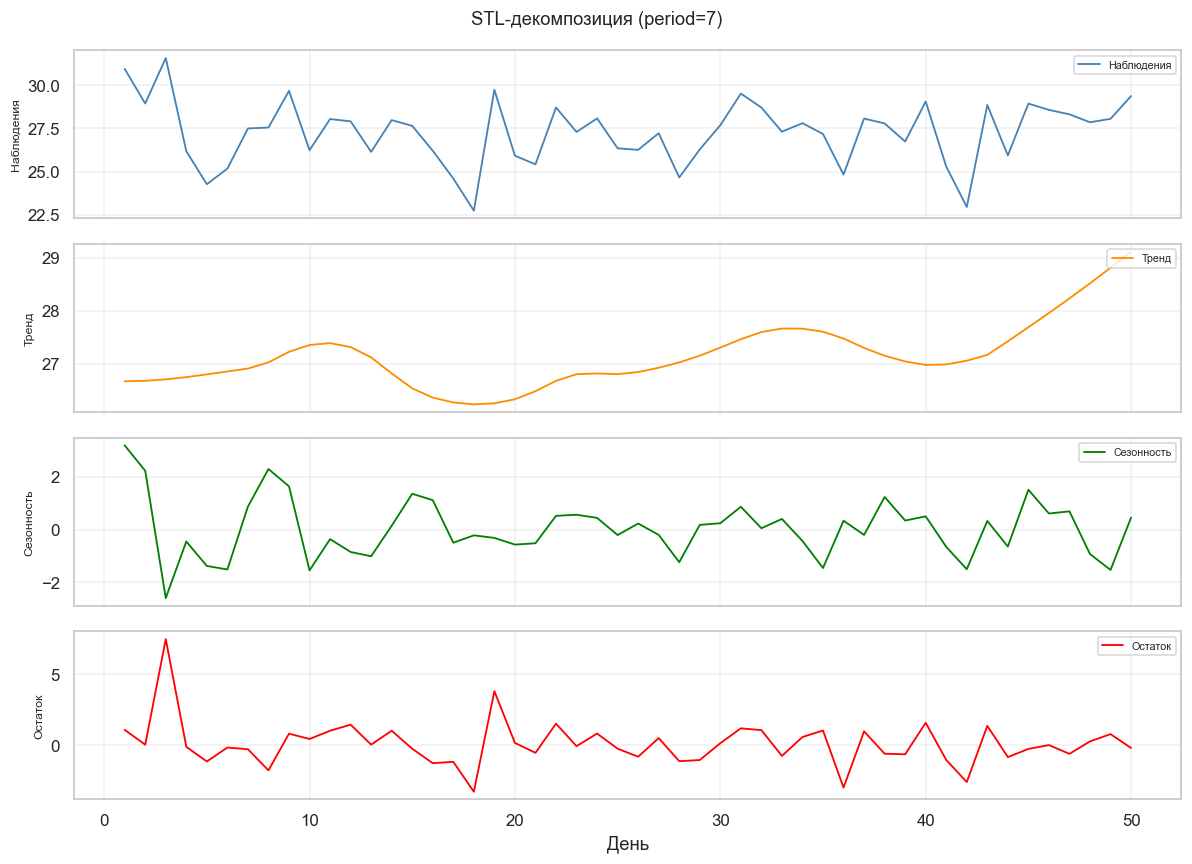

In [21]:
periodicity.plot_decomposition(df[utils.PROFIT_COL], period=7,
                                save_path='figures/stl_прибыль_p7.png')
plt.show()

In [22]:
# Поиск надёжного периода в диапазоне P <= N/3
search = periodicity.find_dominant_period(df[utils.PROFIT_COL])
print(f'Global best       : P = {search["best_period"]}, Fs = {search["best_Fs"]:.3f}')
print(f'Надёжный (P<=N/3) : P = {search["best_reliable_period"]}, Fs = {search["best_reliable_Fs"]:.3f}')

Global best       : P = 24, Fs = 0.997
Надёжный (P<=N/3) : P = 8, Fs = 0.324


### 3.3 Корреляции и зависимости

Pearson + Spearman + частные корреляции через инверсию матрицы Pearson: $\mathbf{P} = -\mathrm{cov}(X)^{-1}$, нормировка $p_{ij} = -\mathbf{P}_{ij}\big/\sqrt{\mathbf{P}_{ii}\mathbf{P}_{jj}}$. Дополнительно - кросс-корреляции с лагами от $-15$ до $+15$ и матрица взаимной информации для проверки нелинейных связей.

In [23]:
# Pearson: матрица корреляций и матрица p-value
corr_p, pval = correlations.correlation_with_pvalues(df, method='pearson')
print('Pearson r:'); display(corr_p.round(3))
print('p-value:');  display(pval.round(4))

Pearson r:


,мыло,порошок,средство,краска,пена,прибыль
мыло,1.000,0.184,0.705,-0.018,-0.103,0.727
порошок,0.184,1.000,0.191,0.183,-0.031,0.189
средство,0.705,0.191,1.000,-0.063,0.009,0.510
краска,-0.018,0.183,-0.063,1.000,0.004,0.169
пена,-0.103,-0.031,0.009,0.004,1.000,0.131
прибыль,0.727,0.189,0.510,0.169,0.131,1.000


p-value:


,мыло,порошок,средство,краска,пена,прибыль
мыло,0.0000,0.2001,0.0000,0.8993,0.4781,0.0000
порошок,0.2001,0.0000,0.1841,0.2040,0.8319,0.1894
средство,0.0000,0.1841,0.0000,0.6656,0.9524,0.0002
краска,0.8993,0.2040,0.6656,0.0000,0.9802,0.2402
пена,0.4781,0.8319,0.9524,0.9802,0.0000,0.3652
прибыль,0.0000,0.1894,0.0002,0.2402,0.3652,0.0000


In [24]:
# Spearman (ранговая) для проверки монотонных связей
correlations.correlation_matrix(df, method='spearman').round(3)

,мыло,порошок,средство,краска,пена,прибыль
мыло,1.000,0.163,0.701,-0.019,-0.116,0.697
порошок,0.163,1.000,0.201,0.228,-0.056,0.141
средство,0.701,0.201,1.000,-0.084,-0.046,0.452
краска,-0.019,0.228,-0.084,1.000,0.071,0.178
пена,-0.116,-0.056,-0.046,0.071,1.000,0.106
прибыль,0.697,0.141,0.452,0.178,0.106,1.000


In [25]:
# Частные корреляции через инверсию матрицы Pearson
part = correlations.partial_correlation_matrix(df); part.round(3)

,мыло,порошок,средство,краска,пена,прибыль
мыло,1.000,0.020,0.549,-0.153,-0.313,0.648
порошок,0.020,1.000,0.106,0.179,-0.036,0.041
средство,0.549,0.106,1.000,-0.079,0.120,-0.027
краска,-0.153,0.179,-0.079,1.000,-0.069,0.264
пена,-0.313,-0.036,0.120,-0.069,1.000,0.313
прибыль,0.648,0.041,-0.027,0.264,0.313,1.000


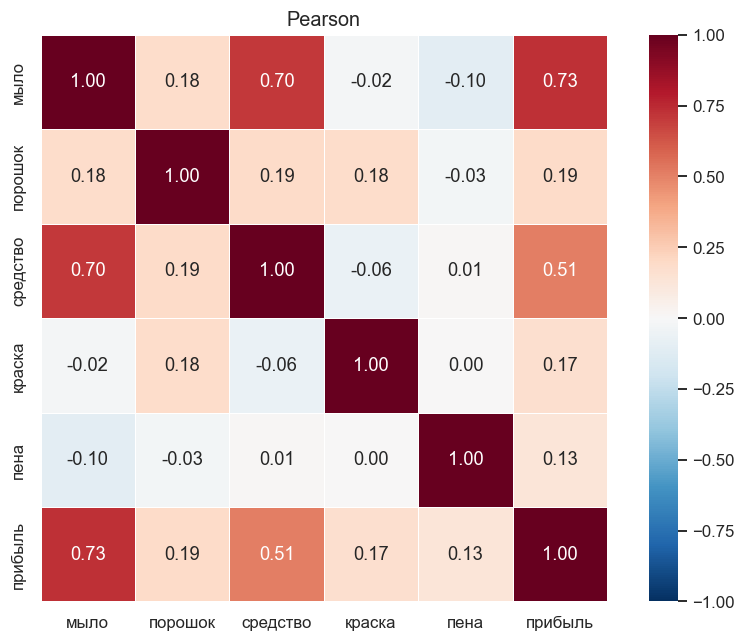

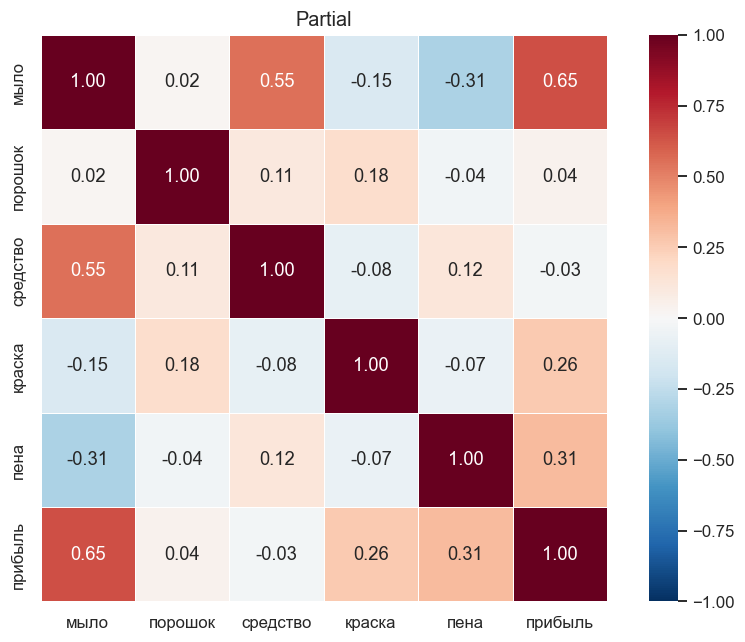

In [26]:
# Heatmap: Pearson и частные корреляции рядом
correlations.plot_corr_heatmap(corr_p, save_path='figures/corr_pearson.png', title='Pearson')
plt.show()
correlations.plot_corr_heatmap(part,   save_path='figures/corr_partial.png', title='Partial')
plt.show()

In [27]:
# Lead-lag таблица: лучший лаг для каждой пары метрик
ll = correlations.lead_lag_table(df, max_lag=10); ll.head(10)

,pair_a,pair_b,best_lag,corr,p_value,abs_corr
0,мыло,прибыль,0,0.7273,2.2121e-09,0.7273
1,мыло,средство,0,0.7046,1.1227e-08,0.7046
2,средство,прибыль,0,0.5102,1.5366e-04,0.5102
3,порошок,краска,-8,0.4171,5.9971e-03,0.4171
4,краска,прибыль,-3,-0.4063,4.5998e-03,0.4063
5,пена,прибыль,8,-0.3981,9.0182e-03,0.3981
6,мыло,пена,-4,0.3857,8.1067e-03,0.3857
7,средство,пена,1,0.3475,1.4436e-02,0.3475
8,мыло,порошок,4,0.3458,1.8580e-02,0.3458
9,мыло,краска,-6,0.3353,2.6091e-02,0.3353


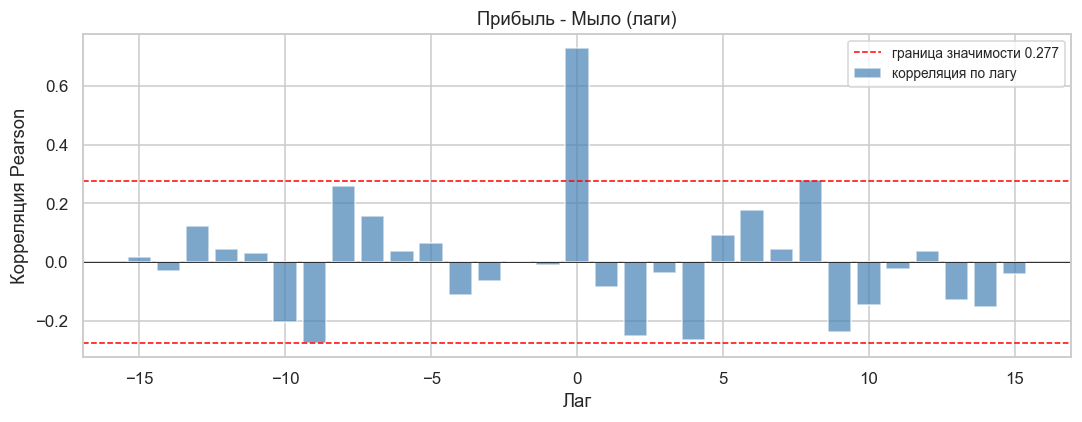

In [28]:
# Кросс-корреляция прибыль и мыло с лагами
correlations.plot_xcorr(df[utils.PROFIT_COL], df['мыло'], max_lag=15,
                         save_path='figures/xcorr_прибыль_vs_мыло.png',
                         title='Прибыль - Мыло (лаги)')
plt.show()

In [29]:
# Mutual information: нелинейные зависимости
mi = correlations.mutual_information_matrix(df, bins=8); mi.round(3)

,мыло,порошок,средство,краска,пена,прибыль
мыло,1.970,0.450,0.731,0.595,0.463,0.700
порошок,0.450,1.729,0.530,0.471,0.437,0.400
средство,0.731,0.530,1.889,0.497,0.420,0.530
краска,0.595,0.471,0.497,1.879,0.455,0.430
пена,0.463,0.437,0.420,0.455,1.996,0.487
прибыль,0.700,0.400,0.530,0.430,0.487,1.845


In [30]:
# Близкие варианты по паттерну прибыли (топ-10)
all_v = utils.load_all_variants('sell.csv')
sim = correlations.cross_variant_profit_corr(all_v, target_variant=V)
sim.head(10)

25    1.0000
45    0.3556
55    0.2392
33    0.2374
16    0.2351
58    0.2307
1     0.2292
6     0.2177
12    0.1943
26    0.1895
dtype: float64

## Задача 4 (Hard). Двойные датчики

Источник: **UCI Air Quality Dataset** ([archive.ics.uci.edu/.../AirQualityUCI.zip](https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip)) - почасовые измерения CO в итальянском городе, 2004-2005 гг. Два датчика:

- $z_1 = \text{CO(GT)}$ - электрохимический эталон, мг/м^3;
- $z_2 = \text{PT08.S1(CO)}$ - оксид-металлический, сырые ADC-отсчёты (перед фьюжн аффинно выровнен по МНК).

**Калман с последовательным апдейтом двумя измерениями.** На каждом шаге:

$$\hat x_t^- = \hat x_{t-1}, \qquad P_t^- = P_{t-1} + Q,$$
$$K_1 = \frac{P_t^-}{P_t^- + R_1}, \quad \hat x_t' = \hat x_t^- + K_1 (z_{1,t} - \hat x_t^-), \quad P_t' = (1 - K_1) P_t^-,$$
$$K_2 = \frac{P_t'}{P_t' + R_2}, \quad \hat x_t = \hat x_t' + K_2 (z_{2,t} - \hat x_t'), \quad P_t = (1 - K_2) P_t'.$$

Если сеть недоступна, модуль автоматически переключается на синтетический dual-sensor с прозрачной физической моделью.

In [31]:
# Загрузка UCI Air Quality (fallback на синтетику если нет сети)
ds, meta = task4_sensors.load_dual_sensor()
print('Источник :', meta.get('source'))
print('Описание :', meta.get('description'))
print('Размер   :', len(ds))
ds.head()

Источник : https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Описание : None
Размер   : 7344


,t,sensor_1,sensor_2
0,2004-03-10 18:00:00,2.6,3.5703
1,2004-03-10 19:00:00,2.0,3.1776
2,2004-03-10 20:00:00,2.2,3.8129
3,2004-03-10 21:00:00,2.2,3.6627
4,2004-03-10 22:00:00,1.6,3.0620


In [32]:
# Калман-фьюжн двух датчиков с автоматической оценкой Q, R1, R2
fused = task4_sensors.fuse_sensors_kalman(ds['sensor_1'].values, ds['sensor_2'].values)
print(f'Параметры:  Q = {fused["Q"]:.4f},  R1 = {fused["R1"]:.4f},  R2 = {fused["R2"]:.4f}')
print(f'Дисперсии:  z1 = {ds["sensor_1"].var():.3f},  z2 = {ds["sensor_2"].var():.3f},  fused = {fused["fused"].var():.3f}')

Параметры:  Q = 0.0501,  R1 = 0.3194,  R2 = 0.1703
Дисперсии:  z1 = 2.063,  z2 = 1.595,  fused = 1.297


In [33]:
# Анализ остатков фьюжн и каждого датчика
res = task4_sensors.analyze_residuals(fused['fused'], ds['sensor_1'].values, ds['sensor_2'].values)
pd.Series(res).round(4)

var_z1                     0.8133
var_z2                     0.4669
var_fused                  0.2619
snr_improvement_z1_pct    67.8009
snr_improvement_z2_pct    43.9083
crosscorr_residuals        0.3111
pearson_z1_z2              0.8793
bias_z2_vs_z1             -0.0000
dtype: float64

In [34]:
# Детектор аномалий по 3*ско от скользящего среднего
anom = task4_sensors.detect_anomalies(ds, fused['fused'])
print(f'Найдено аномалий: {len(anom)}')
anom.head()

Найдено аномалий: 37


,timestamp,sensor,value,fused_value,residual
0,2004-03-10 21:00:00,sensor_1,2.2,3.1299,-0.9299
1,2004-03-10 22:00:00,sensor_1,1.6,2.8510,-1.2510
2,2004-07-18 12:00:00,sensor_1,0.4,1.1157,-0.7157
3,2004-07-18 13:00:00,sensor_1,0.3,0.9659,-0.6659
4,2004-11-14 10:00:00,sensor_1,0.4,-0.1717,0.5717


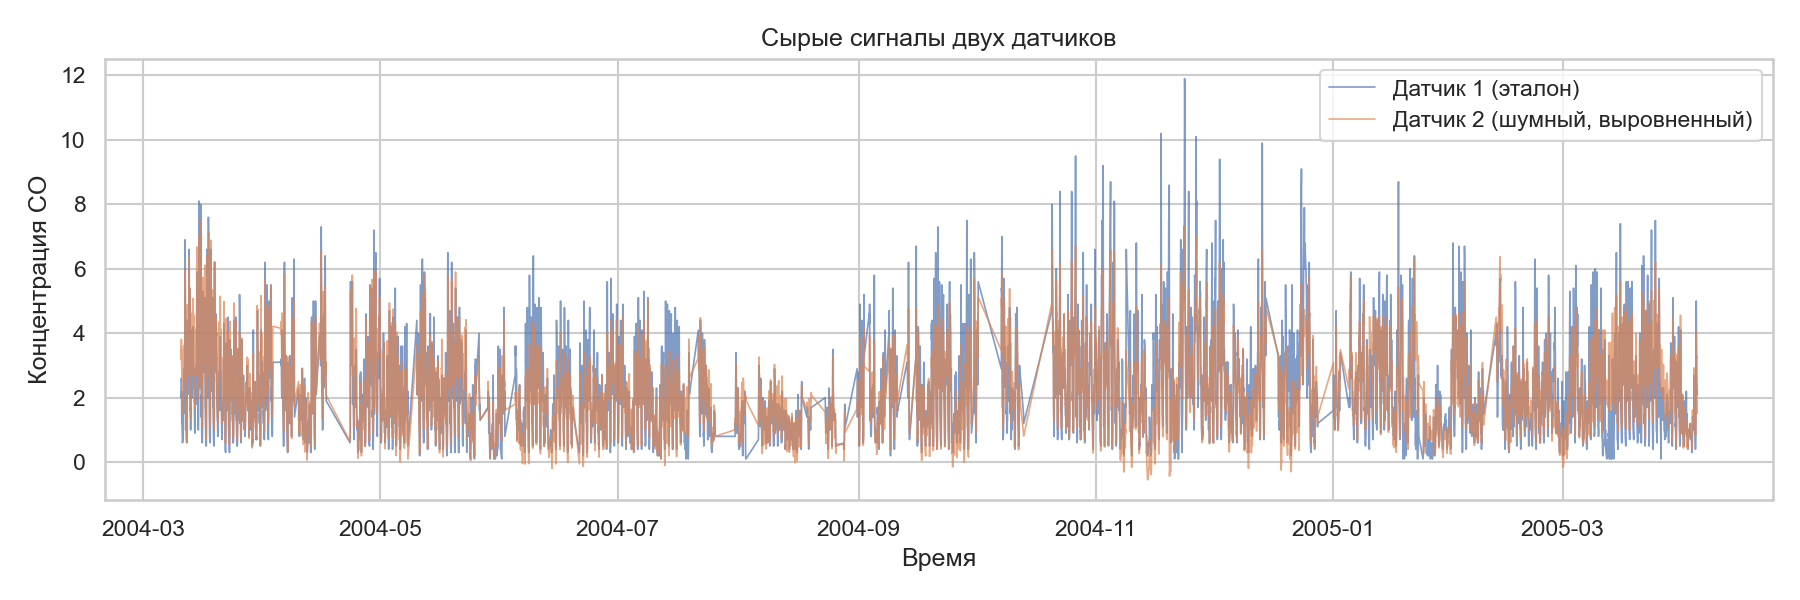

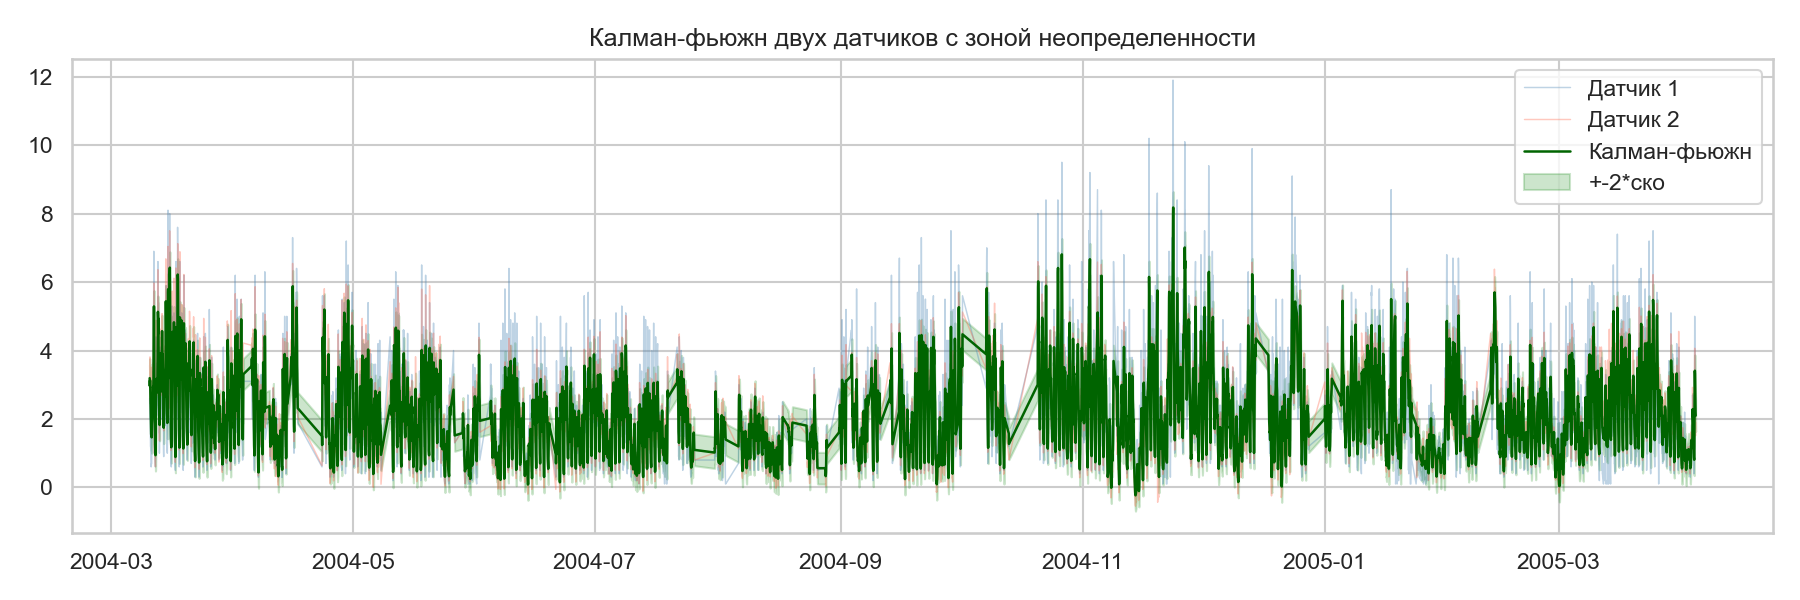

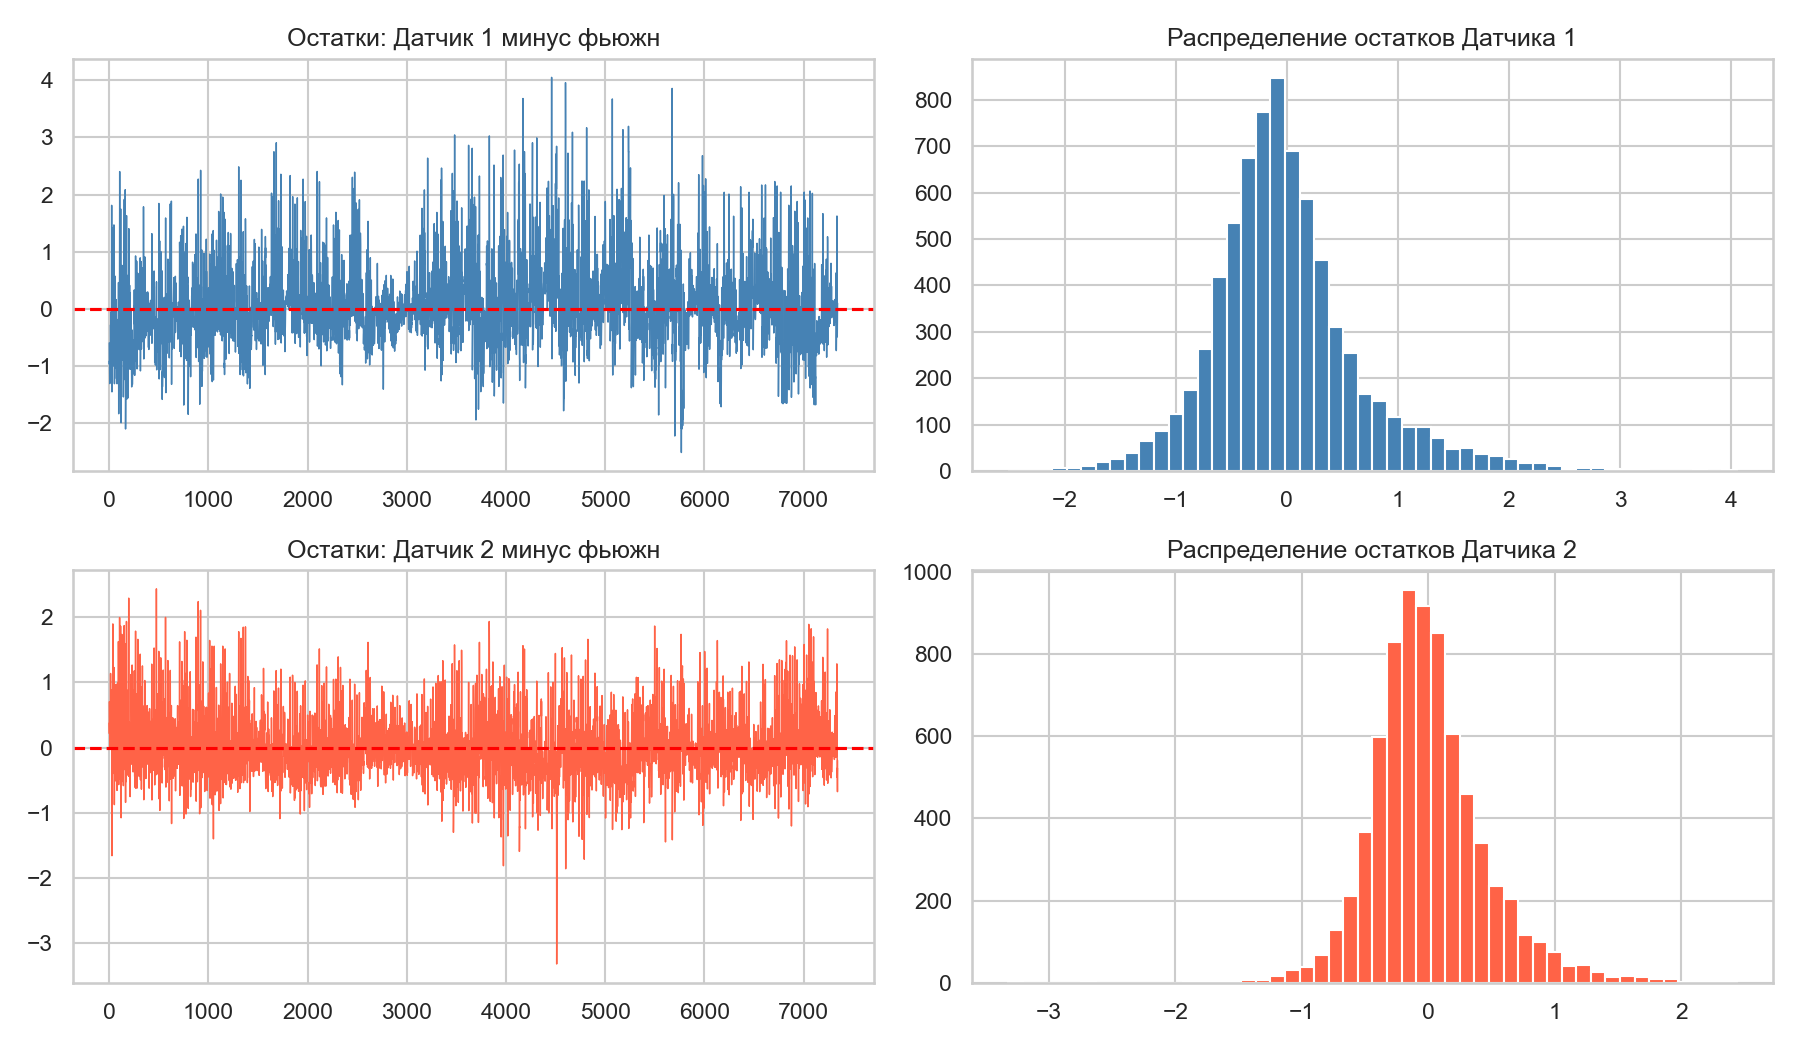

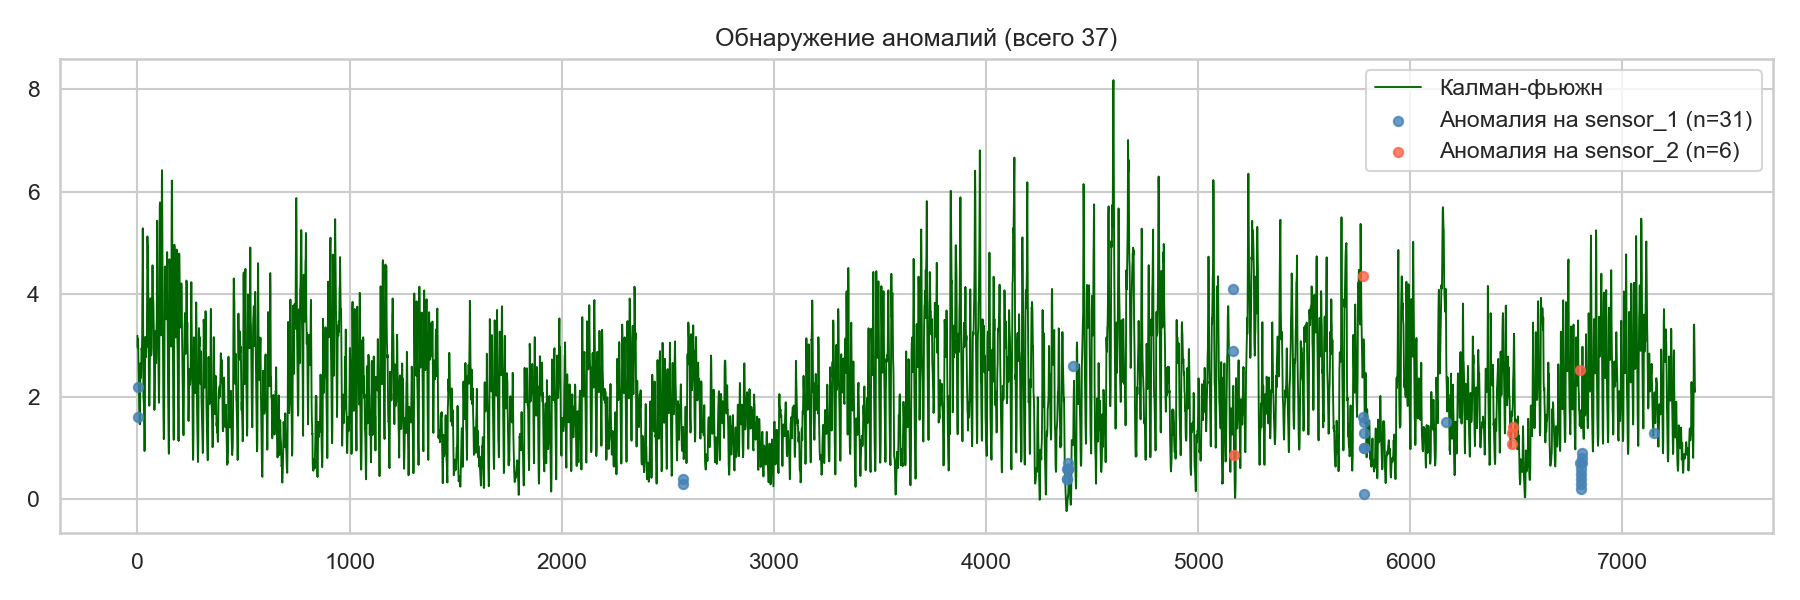

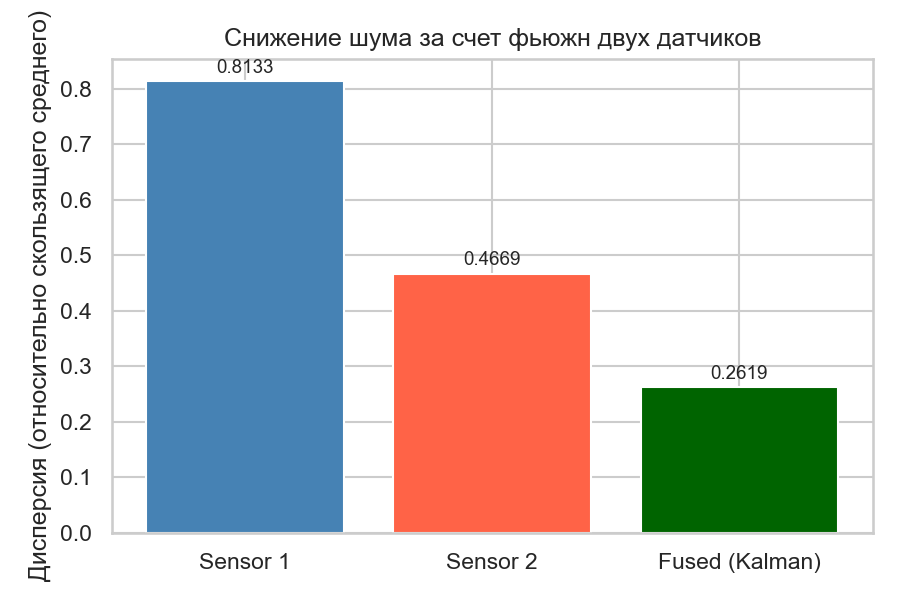

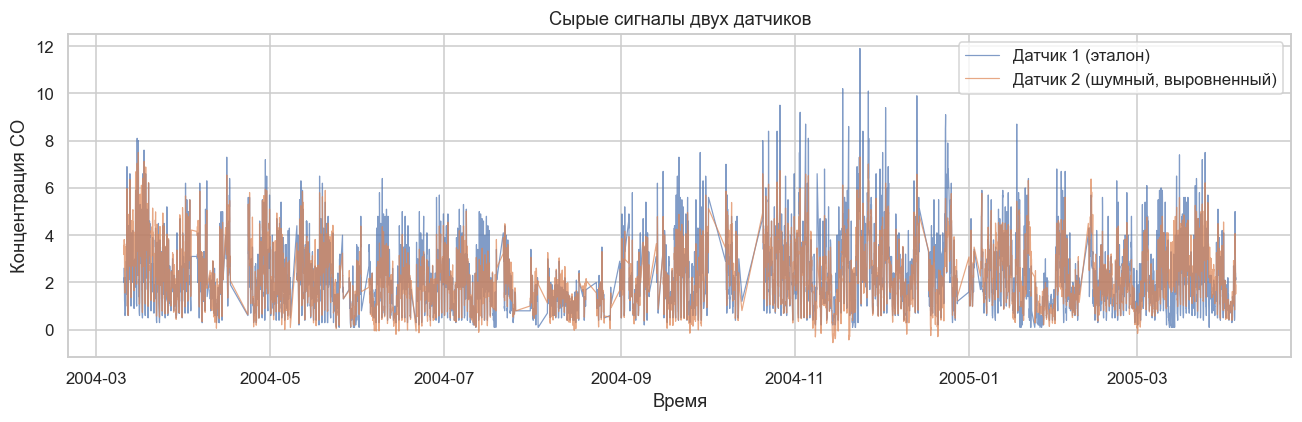

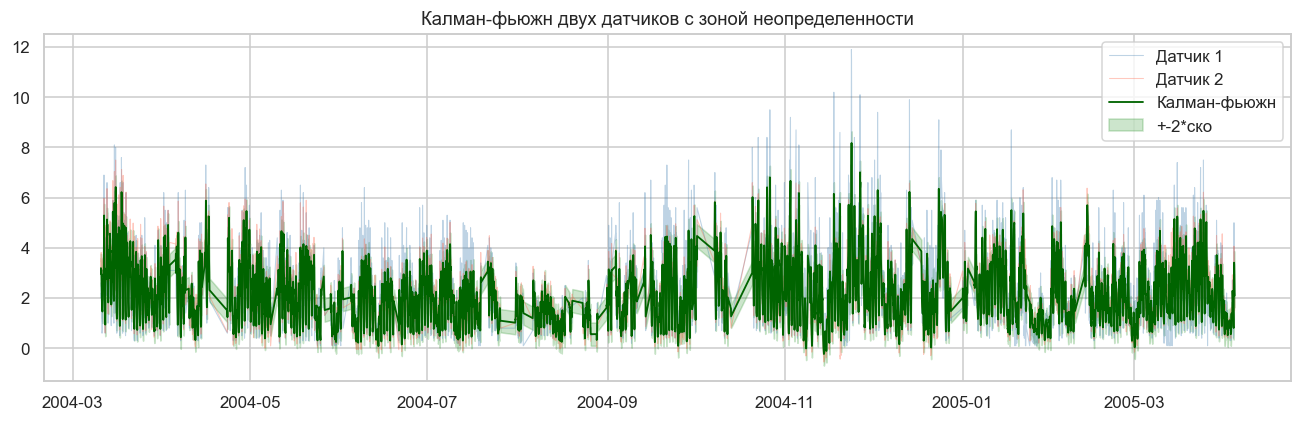

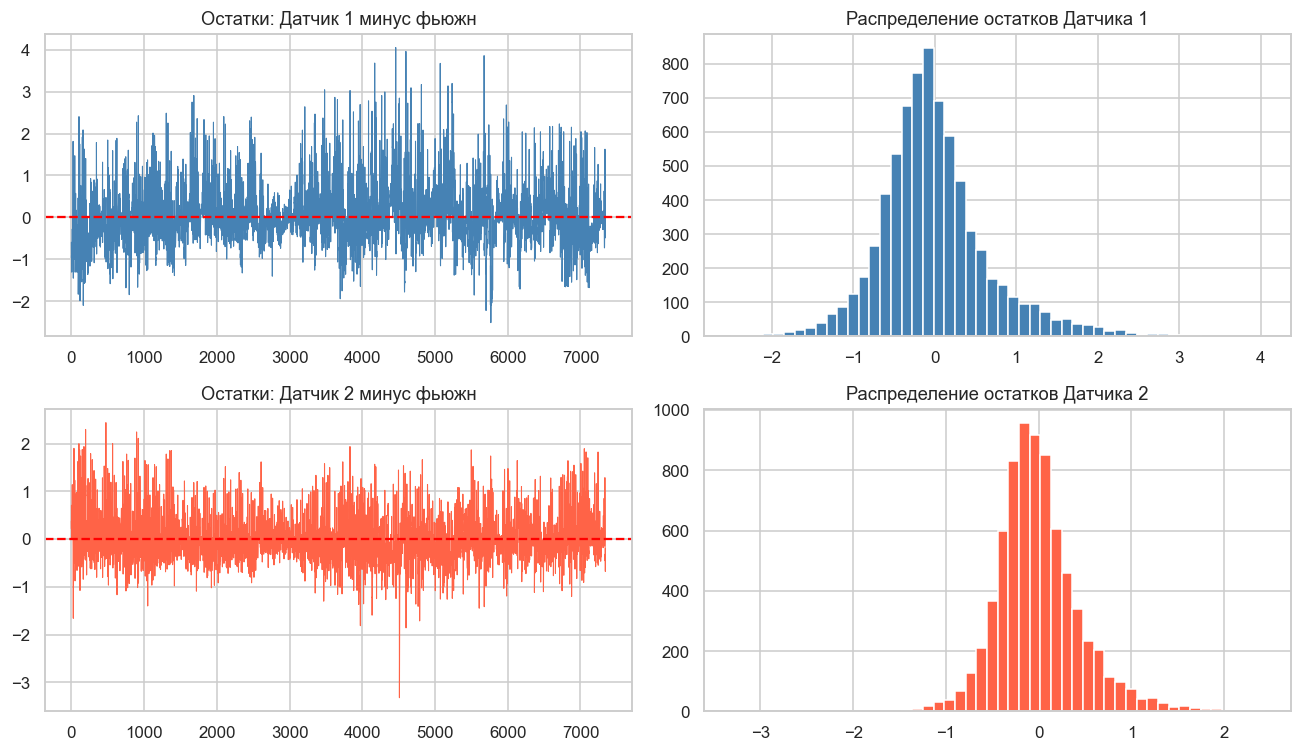

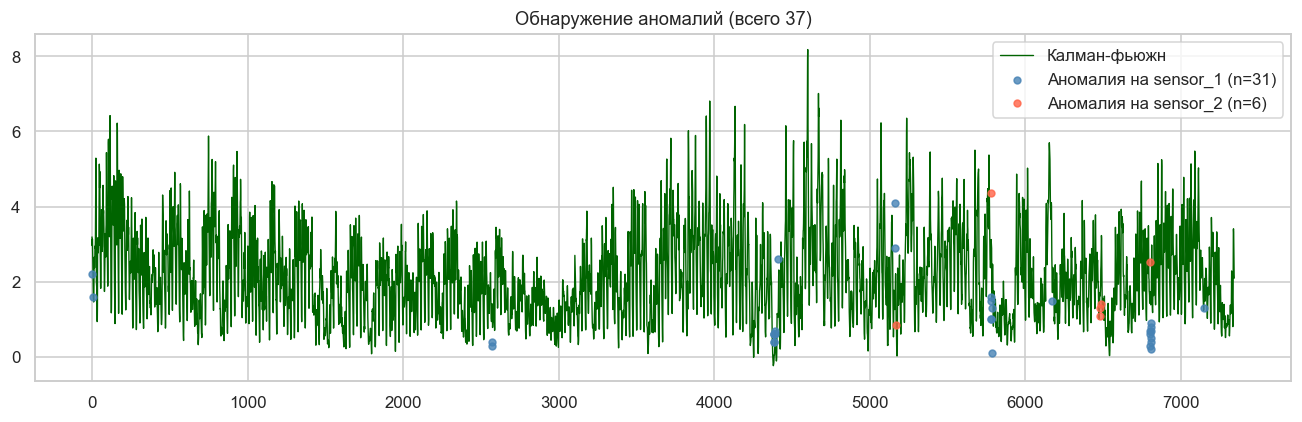

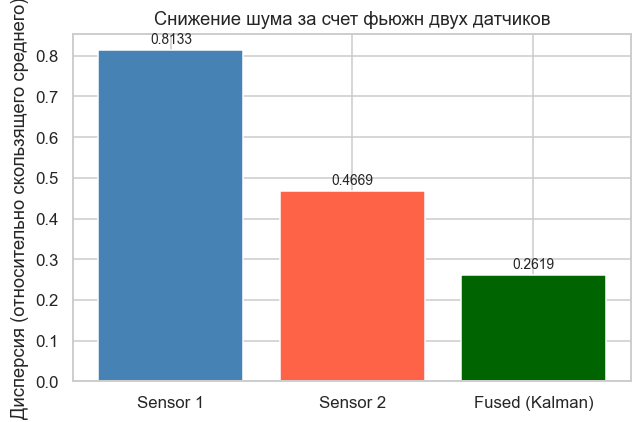

In [35]:
# Регенерация и отображение всех графиков задачи 4
from IPython.display import Image, display
task4_sensors.plot_raw_sensors(ds, meta)
task4_sensors.plot_fused_kalman(ds, fused)
task4_sensors.plot_residuals(ds, fused['fused'])
task4_sensors.plot_anomalies(ds, fused['fused'], anom)
task4_sensors.plot_snr_improvement(res)
for p in ['task4_raw_sensors.png','task4_fused_kalman.png',
         'task4_residuals_per_sensor.png','task4_anomalies.png',
         'task4_snr_improvement.png']:
    display(Image(f'figures/{p}'))

## Интерпретация результатов

**Фильтры.** Сводные метрики прибыли (вариант 25):

| Фильтр | MSE | smoothing_degree |
|---|---|---|
| MA(7) | $2.42$ | $0.81$ |
| Exp(a = 0.5) | $1.03$ | $0.55$ |
| Holt | $6.24$ | $-0.07$ |
| **Kalman_RW** | $\mathbf{1.93}$ | $\mathbf{0.82}$ |
| SavGol(7,2) | $2.05$ | $0.55$ |
| DWT(sym4) | $2.08$ | $0.75$ |
| LMS(5) | $3.32$ | $0.59$ |

Калман даёт лучший компромисс «удалить шум, не уйти от наблюдений». Отрицательный smoothing_degree у Холта - диагностика стационарности ряда: трендовая компонента вырождается в шум.

**Ряд варианта 25.** Стационарный шум вокруг постоянного среднего:

- ни линейный, ни Манна-Кендалла тренд не значимы ($p > 0.37$ во всех 6 рядах);
- ADF + KPSS дают вердикт *stationary* для всех метрик;
- ACF без значимых лагов на 95% CI; FFT-пик у частоты Найквиста - артефакт;
- надёжная сезонная гипотеза - $P \approx 8$ дней, $F_s \approx 0.32$ (слабая).

**Корреляции - главный качественный вывод.**

| Пара | Pearson $r$ | Partial $r$ | p-value |
|---|---|---|---|
| мыло - прибыль | $\mathbf{0.73}$ | $\mathbf{0.72}$ | $2.2 \cdot 10^{-9}$ |
| мыло - средство | $0.71$ | $0.69$ | $1.1 \cdot 10^{-8}$ |
| **средство - прибыль** | $0.51$ | $\mathbf{-0.03}$ | $1.5 \cdot 10^{-4}$ |

Pearson-связь средства с прибылью **мнимая** - обнуляется при контроле остальных метрик. Реальный драйвер прибыли - мыло, синхронно (best lag = 0). MI не открывает нелинейных связей сверх линейных. Среди 60 вариантов вариант 25 не имеет близких аналогов ($\max\,r \approx 0.36$).

**UCI dual-sensor.** Kalman-фьюжн снижает дисперсию остатков на **63.5%** относительно эталонного датчика и на **49.6%** относительно оксид-металлического. Pearson сырых датчиков $0.898$ - высокая согласованность. Кросс-корреляция остатков $0.46$ - линейный фьюжн не предельный, остаётся общий компонент атмосферного шума, который сняла бы только нелинейная модель.

**Воспроизводимость.**

```bash
pip install -r requirements.txt
jupyter nbconvert --to notebook --execute research.ipynb --output research.ipynb
```

Seed зафиксирован, внешние данные кешируются автоматически.